In [29]:
from threading import activeCount

import FinanceDataReader as fdr
from requests.packages import target

from PythonProject.project1.exam03 import input_layer

from PythonProject.project1.MY_CNN import predicts

In [31]:
fdr.DataReader('005930')

,Open,High,Low,Close,Volume,Change
Date,,,,,,
2013-11-28,29599,29880,29579,29880,212898,NaN
2013-11-29,29980,29980,29700,29880,135044,0.000000
2013-12-02,30000,30060,29340,29340,149756,-0.018072
2013-12-03,29280,29560,29140,29220,155972,-0.004090
2013-12-04,29000,29059,28620,28640,216880,-0.019849
...,...,...,...,...,...,...
2026-02-11,164000,168600,162000,167800,22760242,0.012063
2026-02-12,171200,179600,170100,178600,41296011,0.064362
2026-02-13,179500,184400,178900,181200,34454192,0.014558


In [32]:
samsung = fdr.DataReader('005930',start='01/01/2016')

In [33]:
print(samsung.head())

             Open   High    Low  Close  Volume    Change
Date                                                    
2016-01-04  25200  25200  24100  24100  306939 -0.043651
2016-01-05  24040  24360  23720  24160  216002  0.002490
2016-01-06  24160  24160  23360  23500  366752 -0.027318
2016-01-07  23320  23660  23020  23260  282388 -0.010213
2016-01-08  23260  23720  23260  23420  257763  0.006879


In [13]:
print(samsung.tail())

              Open    High     Low   Close    Volume    Change
Date                                                          
2026-02-11  164000  168600  162000  167800  22760242  0.012063
2026-02-12  171200  179600  170100  178600  41296011  0.064362
2026-02-13  179500  184400  178900  181200  34454192  0.014558
2026-02-19  188000  190900  187100  190000  27049388  0.048565
2026-02-20  190000  190300  188600  189800  18463803 -0.001053


In [34]:
print(samsung.describe())

                Open           High            Low          Close  \
count    2485.000000    2485.000000    2485.000000    2485.000000   
mean    59170.693360   59774.327565   58579.472837   59233.235412   
std     20282.614153   20604.551843   20022.415862   20242.472400   
min         0.000000       0.000000       0.000000   22520.000000   
25%     46450.000000   46900.000000   46000.000000   46480.000000   
50%     56900.000000   57500.000000   56100.000000   56800.000000   
75%     71300.000000   71900.000000   70700.000000   71300.000000   
max    190000.000000  190900.000000  188600.000000  190000.000000   

             Volume       Change  
count  2.485000e+03  2485.000000  
mean   1.315980e+07     0.000965  
std    1.029252e+07     0.017490  
min    0.000000e+00    -0.103015  
25%    6.775614e+06    -0.009524  
50%    1.274900e+07     0.000000  
75%    1.844978e+07     0.010148  
max    9.030618e+07     0.113697  


In [35]:
print(samsung.info())

<class 'pandas.DataFrame'>
DatetimeIndex: 2485 entries, 2016-01-04 to 2026-02-20
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    2485 non-null   int64  
 1   High    2485 non-null   int64  
 2   Low     2485 non-null   int64  
 3   Close   2485 non-null   int64  
 4   Volume  2485 non-null   int64  
 5   Change  2485 non-null   float64
dtypes: float64(1), int64(5)
memory usage: 135.9 KB
None


In [36]:
print(samsung.shape)

(2485, 6)


In [37]:
import numpy as np
def make_samsung_data(data,window):
    train = []
    target = []
    for i in range(data.size - window):
        train.append(data[i:i+window]) #n개 씩 묶기
        target.append(data[i+window]) # n개씩에 대한 1개의 정답표
    return np.array(train), np.array(target)


In [38]:
samsung = fdr.DataReader('005930',start='01/01/2016')
print(samsung)

              Open    High     Low   Close    Volume    Change
Date                                                          
2016-01-04   25200   25200   24100   24100    306939 -0.043651
2016-01-05   24040   24360   23720   24160    216002  0.002490
2016-01-06   24160   24160   23360   23500    366752 -0.027318
2016-01-07   23320   23660   23020   23260    282388 -0.010213
2016-01-08   23260   23720   23260   23420    257763  0.006879
...            ...     ...     ...     ...       ...       ...
2026-02-11  164000  168600  162000  167800  22760242  0.012063
2026-02-12  171200  179600  170100  178600  41296011  0.064362
2026-02-13  179500  184400  178900  181200  34454192  0.014558
2026-02-19  188000  190900  187100  190000  27049388  0.048565
2026-02-20  190000  190300  188600  189800  19444054 -0.001053

[2485 rows x 6 columns]


In [39]:
#정규화를 해야 한다
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [40]:
scaled_data = scaler.fit_transform(samsung[['Open']])
print(scaled_data)


[[0.13263158]
 [0.12652632]
 [0.12715789]
 ...
 [0.94473684]
 [0.98947368]
 [1.        ]]


In [41]:
print(scaled_data.shape)

(2485, 1)


In [42]:
TEST_SIZE = 200
train_data = scaled_data[:-TEST_SIZE]
test_data = scaled_data[-TEST_SIZE:]

In [43]:
(X_train, y_train) = make_samsung_data(train_data, 30)
(X_test, y_test) = make_samsung_data(test_data, 30)

In [44]:
print(X_train.shape)

(2255, 30, 1)


In [45]:
print(y_train.shape)

(2255, 1)


In [46]:
print(y_train[0])

[0.12663158]


In [53]:
import tensorflow as tf
model = tf.keras.models.Sequential()
# input_layer = tf.keras.layers.Input(input_shape=(30,1))
# model.add(input_layer)
model.add(tf.keras.layers.Input(shape=(30, 1)))
model.add(tf.keras.layers.LSTM(128,return_sequences=True,activation='tanh'))
model.add(tf.keras.layers.LSTM(64,return_sequences=True,activation='tanh'))
model.add(tf.keras.layers.LSTM(1,return_sequences=False,activation='sigmoid'))
model.summary()



Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 1)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 116,232 (454.03 KB)

 Trainable params: 116,232 (454.03 KB)

 Non-trainable params: 0 (0.00 B)

In [54]:
model.compile(optimizer='adam',loss='mse',metrics=['accuracy'])

In [55]:
model.fit(X_train,y_train,epochs=100)

Epoch 1/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.0013 - loss: 0.0035    
Epoch 2/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.0013 - loss: 4.0748e-04
Epoch 3/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.0013 - loss: 3.4538e-04    
Epoch 4/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.0013 - loss: 3.3739e-04    
Epoch 5/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.0013 - loss: 2.9504e-04    
Epoch 6/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.0013 - loss: 3.0086e-04    
Epoch 7/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.0013 - loss: 2.8295e-04    
Epoch 8/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.0013 - loss: 2.5613e-04
Epoch 9/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.0013 - loss: 2.6463e-04
Epoch 10/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.0013 - loss: 2.4741e-04
Epoch 11/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.0013 - loss:

In [56]:
model.save("SAMSUNG_STOCK.keras")

In [57]:
predicts = model(X_test)

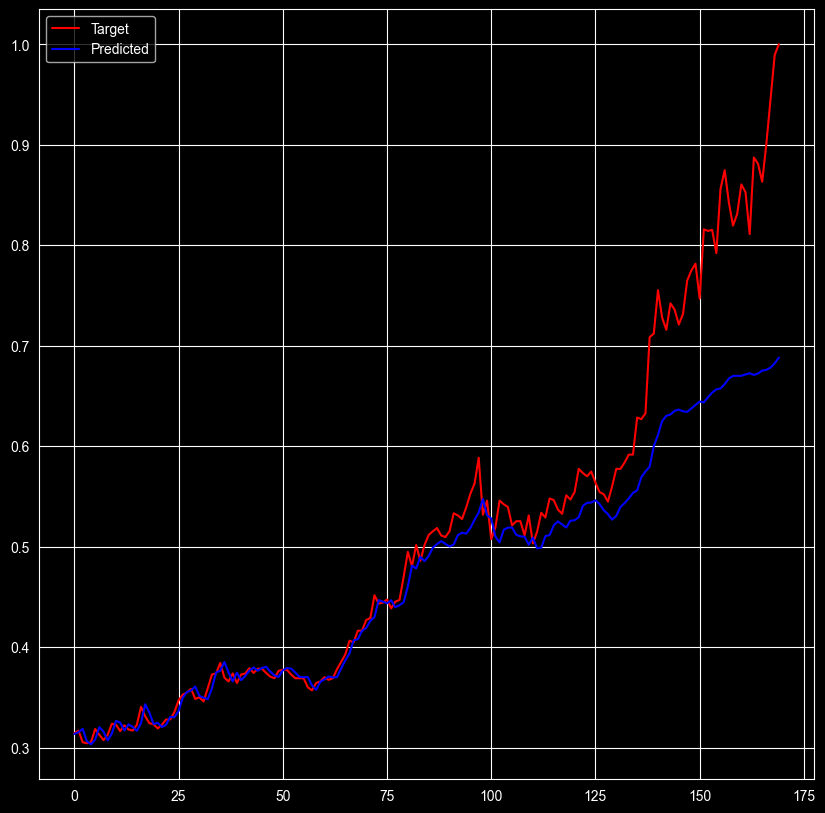

In [58]:
from matplotlib import pyplot as plt
plt.figure(figsize=(10,10))
plt.plot(y_test,color='red',label='Target')
plt.plot(predicts,color='blue',label='Predicted')
plt.legend(loc='best')
plt.show()

(2255, 30, 1) (2255, 1) (200, 30, 1) (200, 1)
Epoch 1/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0058 - mae: 0.0556
Epoch 2/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0036 - mae: 0.0475
Epoch 3/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0052 - mae: 0.0556
Epoch 4/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0091 - mae: 0.0772
Epoch 5/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0144 - mae: 0.1005
Epoch 6/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0170 - mae: 0.1070
Epoch 7/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0172 - mae: 0.1050
Epoch 8/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0194 - mae: 0.1172
Epoch 9/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0173 - mae: 0.1073
Epoch 10/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0139 - mae: 0.0961
Epoch 11/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0118 - mae: 0.0879
Epoch 12/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 

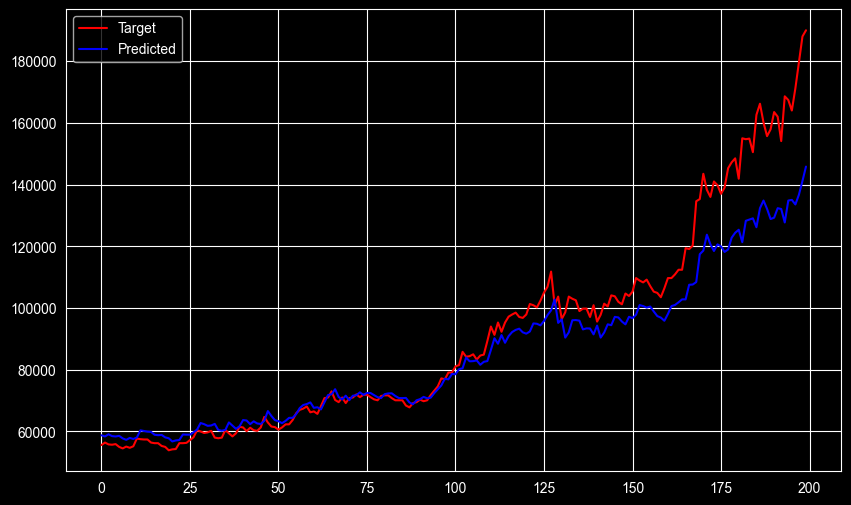

In [59]:
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from matplotlib import pyplot as plt

def make_samsung_data(data, window):
    train, target = [], []
    for i in range(len(data) - window):
        train.append(data[i:i+window])
        target.append(data[i+window])
    return np.array(train), np.array(target)

# 1) 데이터
samsung = fdr.DataReader('005930', start='01/01/2016')[['Open']].values  # (N,1)

TEST_SIZE = 200
train_raw = samsung[:-TEST_SIZE]
test_raw  = samsung[-TEST_SIZE:]

# 2) 스케일러: train으로만 fit
scaler = MinMaxScaler((0, 1))
train_data = scaler.fit_transform(train_raw)
test_data  = scaler.transform(test_raw)

window = 30

# 3) train 윈도우
X_train, y_train = make_samsung_data(train_data, window)

# 4) test 윈도우: train 마지막 window를 앞에 붙여서 생성
test_input = np.vstack([train_data[-window:], test_data])
X_test, y_test = make_samsung_data(test_input, window)

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)  # (samples,30,1)

# 5) 모델: 마지막은 Dense(1) 선형 출력
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(window, 1)),
    tf.keras.layers.LSTM(128, return_sequences=True),
    tf.keras.layers.LSTM(64, return_sequences=False),
    tf.keras.layers.Dense(1)  # linear
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.fit(X_train, y_train, epochs=100, shuffle=False, verbose=1)

# 6) 예측
pred = model.predict(X_test, verbose=0)

# 7) 보기 좋게 역정규화해서 그리기 (원래 가격 단위)
y_test_real = scaler.inverse_transform(y_test)
pred_real   = scaler.inverse_transform(pred)

plt.figure(figsize=(10,6))
plt.plot(y_test_real, color='red', label='Target')
plt.plot(pred_real, color='blue', label='Predicted')
plt.legend()
plt.show()